In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV_FILE = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)

    df['datetime'] = pd.to_datetime(df['Start date'])
    df = df.set_index('datetime') # to change 0, 1, 2, index in to date itself
    
    load_col = 'grid load [MWh] Original resolutions'
    df = df[[load_col]].rename(columns={load_col: 'load_mwh'}) 
    
    return df

df_load = smard_csv(CSV_FILE)

df = df_load

df = df.dropna()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour
df['is_weekend'] = df.index.weekday >= 5
df['day_of_year'] = df.index.dayofyear

print(f"Data processed: {df.index.min()} to {df.index.max()}")
df.tail()

/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/4136758942.py:9: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/4136758942.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['Start date'])


Data processed: 2020-01-01 00:00:00 to 2025-12-31 23:45:00


,load_mwh,year,month,hour,is_weekend,day_of_year
datetime,,,,,,
2025-12-31 22:45:00,12092.33,2025,12,22,False,365
2025-12-31 23:00:00,11954.01,2025,12,23,False,365
2025-12-31 23:15:00,11905.14,2025,12,23,False,365
2025-12-31 23:30:00,11818.62,2025,12,23,False,365
2025-12-31 23:45:00,11756.82,2025,12,23,False,365


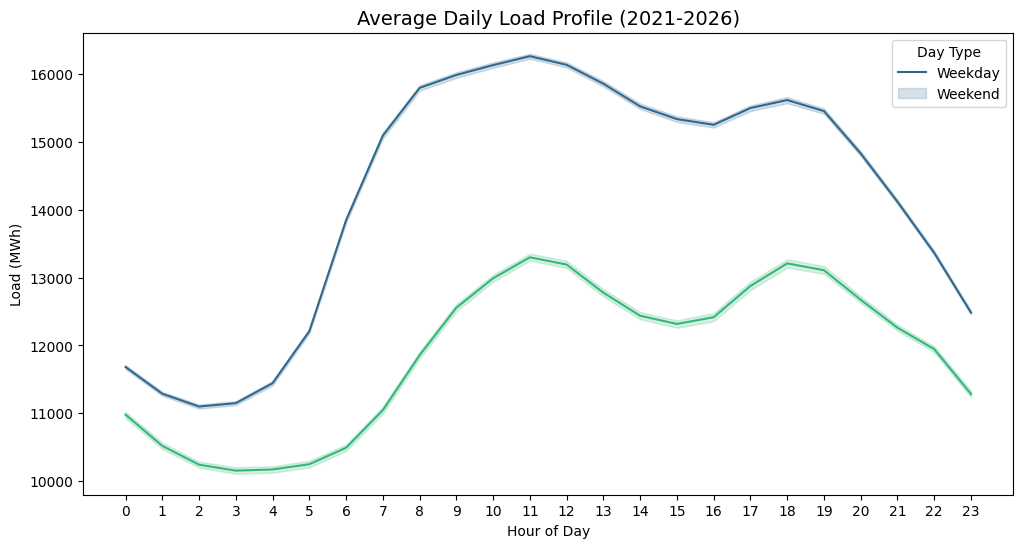

'\n4-8, climbing from ~11,100 MWh to ~15,800 MWh\nPeak demand hits around hour 11 (11 AM) at approximately 16,500 MWh\nEvening decline begins after hour 19, dropping sharply to ~12,600 MWh by hour 23\n'

In [6]:
plt.figure(figsize=(12, 6))
df_recent = df[df['year'] >= 2021]

sns.lineplot(data=df_recent, x='hour', y='load_mwh', hue='is_weekend', palette="viridis")
plt.title("Average Daily Load Profile (2021-2026)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Load (MWh)")
plt.xticks(range(24))
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])
plt.show()

"""
4-8, climbing from ~11,100 MWh to ~15,800 MWh
Peak demand hits around hour 11 (11 AM) at approximately 16,500 MWh
Evening decline begins after hour 19, dropping sharply to ~12,600 MWh by hour 23
"""


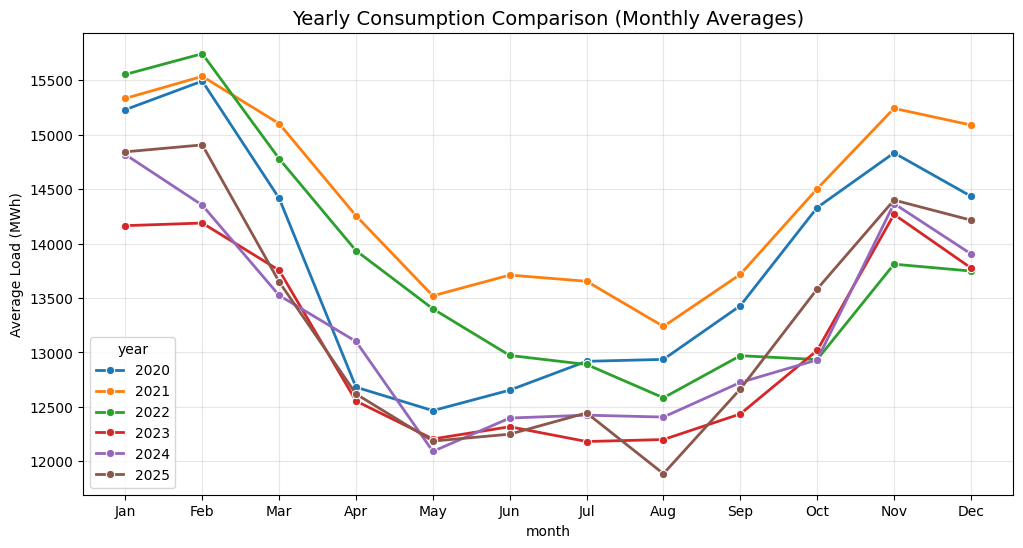

'\nEnergy use is highest in winter.\nIt drops sharply in spring.\nSummer has the lowest and most stable demand.\nConsumption rises again in autumn.\nBiggest jump = October and November.\n'

In [7]:
monthly = df[df['year'].between(2020, 2025)].groupby(['year', 'month'])['load_mwh'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='load_mwh', hue='year', palette="tab10", marker='o', linewidth=2)
plt.title("Yearly Consumption Comparison (Monthly Averages)", fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel("Average Load (MWh)")
plt.grid(True, alpha=0.3)
plt.show()

'''
Energy use is highest in winter.
It drops sharply in spring.
Summer has the lowest and most stable demand.
Consumption rises again in autumn.
Biggest jump = October and November.
'''


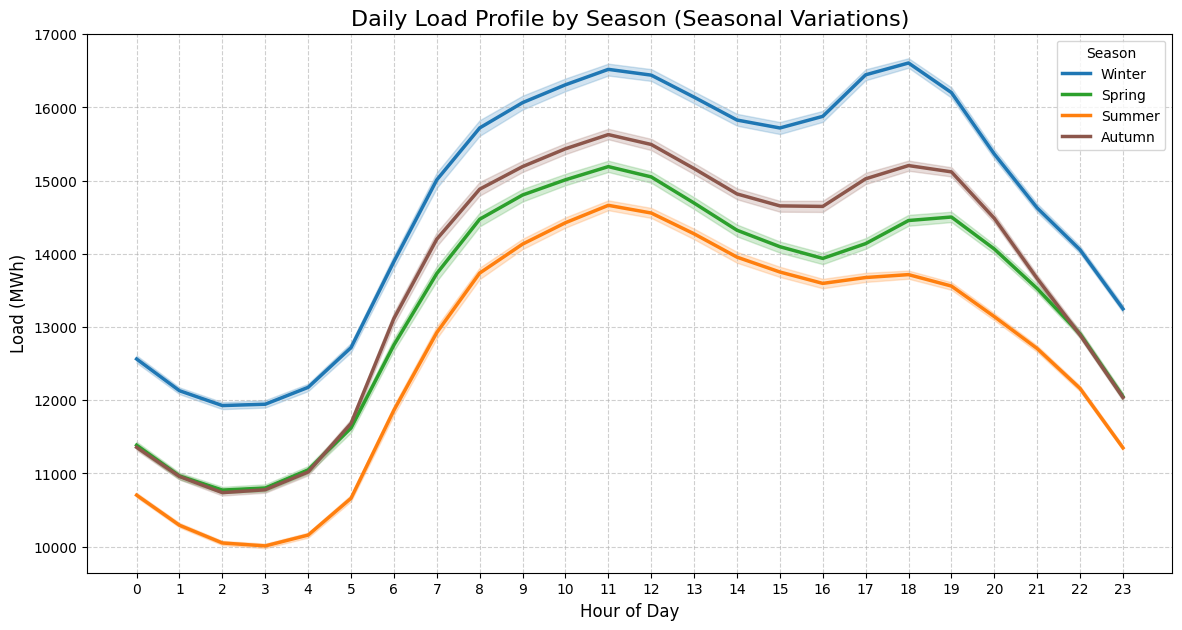

Average Load by Season:
season
Winter    14731.154349
Spring    13347.749023
Summer    12669.779323
Autumn    13674.001922
Name: load_mwh, dtype: float64


In [12]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else: # 9 10 11
        return 'Autumn'

df['season'] = df['month'].apply(get_season)
plt.figure(figsize=(14, 7)) # width and height

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {"Winter": "#1f77b4", "Spring": "#2ca02c", "Summer": "#ff7f0e", "Autumn": "#8c564b"}

sns.lineplot(
    data=df, 
    x='hour', 
    y='load_mwh', 
    hue='season', 
    hue_order=season_order,
    palette=season_colors,
    linewidth=2.5
)

plt.title("Daily Load Profile by Season (Seasonal Variations)", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Load (MWh)", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Season", fontsize=10)

plt.show()

# average load per season for comparison
print("Average Load by Season:")
print(df.groupby('season')['load_mwh'].mean().reindex(season_order))

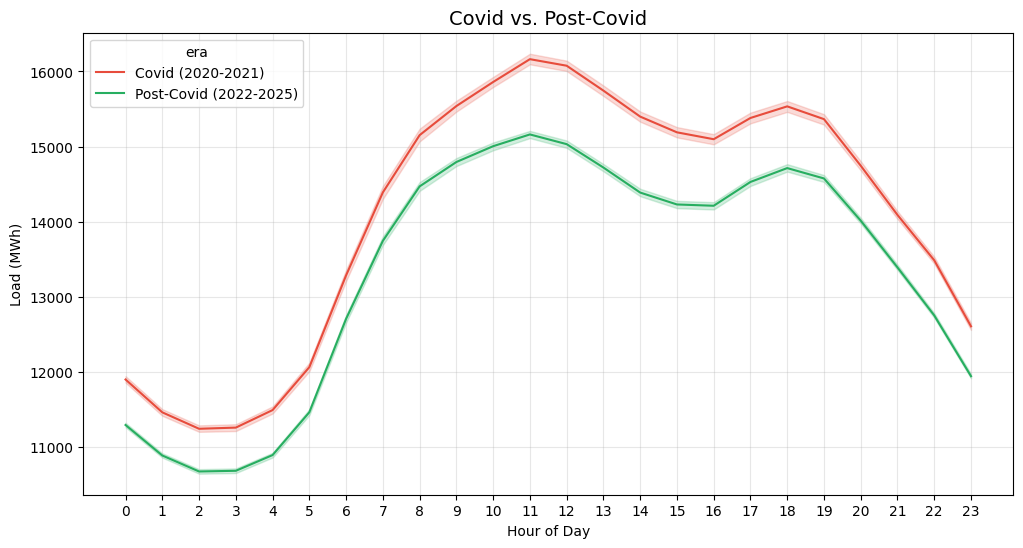

Average Load Comparison:
era
Covid (2020-2021)         14106.793997
Post-Covid (2022-2025)    13347.009928
Name: load_mwh, dtype: float64


In [15]:
def categorize_era(year):
    if year in [2020, 2021]:
        return 'Covid (2020-2021)'
    elif year >= 2022:
        return 'Post-Covid (2022-2025)'
    else:
        return 'Pre-Covid' # not data for

df['era'] = df['year'].apply(categorize_era)

# plot the hourly profiles
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='load_mwh', hue='era', palette=['#e74c3c', '#27ae60'])

plt.title("Covid vs. Post-Covid", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Load (MWh)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

# statistics
stats = df.groupby('era')['load_mwh'].mean()
print("Average Load Comparison:")
print(stats)

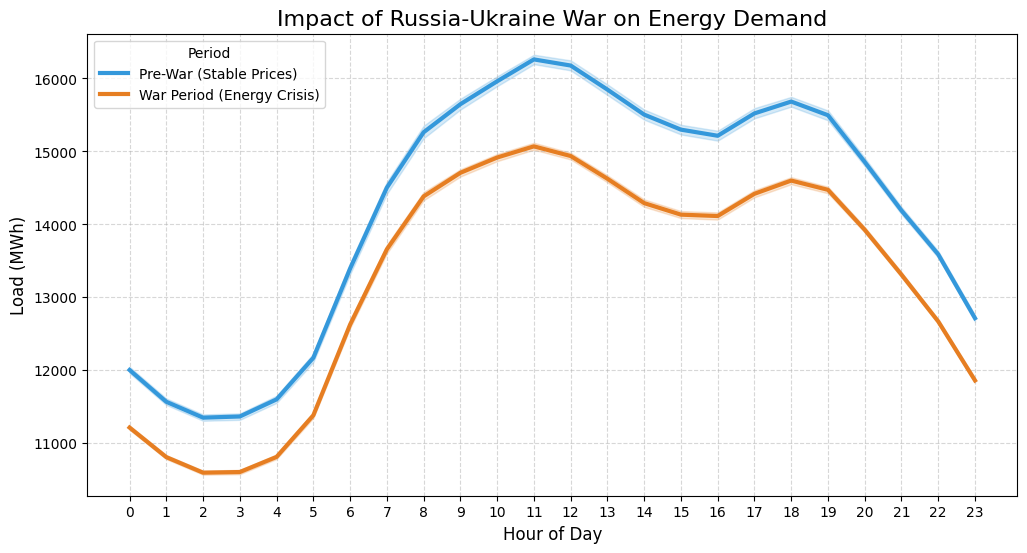

Average Load Pre-War:  14216.40 MWh
Average Load Post-War: 13256.70 MWh
Total Consumption Drop: 6.75%


In [16]:
war_start_date = pd.Timestamp('2022-02-24')

df['war_period'] = df.index.map(lambda x: 'Pre-War' if x < war_start_date else 'War Period')

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df, 
    x='hour', 
    y='load_mwh', 
    hue='war_period', 
    hue_order=['Pre-War (Stable Prices)', 'War Period (Energy Crisis)'],
    palette=['#3498db', '#e67e22'],
    linewidth=3
)

plt.title("Impact of Russia-Ukraine War on Energy Demand", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Load (MWh)", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Period")

plt.show()

stats = df.groupby('war_period')['load_mwh'].mean()
pre_war = stats['Pre-War (Stable Prices)']
post_war = stats['War Period (Energy Crisis)']
drop_pct = ((pre_war - post_war) / pre_war) * 100

print(f"Average Load Pre-War:  {pre_war:.2f} MWh")
print(f"Average Load Post-War: {post_war:.2f} MWh")
print(f"Total Consumption Drop: {drop_pct:.2f}%")

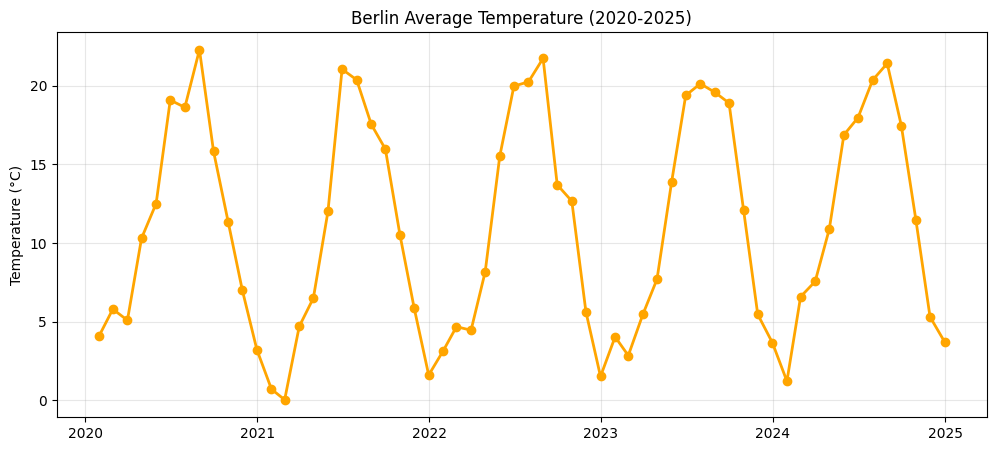

In [20]:
import requests
url = "https://archive-api.open-meteo.com/v1/archive?latitude=52.52&longitude=13.41&start_date=2020-01-01&end_date=2024-12-31&hourly=temperature_2m"
data = requests.get(url).json()

df_weather = pd.DataFrame({
    'date': pd.to_datetime(data['hourly']['time']),
    'temp': data['hourly']['temperature_2m']
})
df_weather.set_index('date', inplace=True)

df_monthly = df_weather.resample('ME').mean()

plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly['temp'], color='orange', linewidth=2, marker='o')
plt.title("Berlin Average Temperature (2020-2025)")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()